## Importación de librerías

In [2]:
!pip install pandas openpyxl


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Carga de datos y leer todas las hojas del archivo Excel

In [ ]:
import pandas as pd

# Ruta del archivo Excel
archivo_excel = '../data/raw/customer-details.xlsx'

# Leer todas las hojas en un diccionario
hojas = pd.read_excel(archivo_excel, sheet_name=None)

# Ver los nombres de las hojas
print("Hojas encontradas:", hojas.keys())

Hojas encontradas: dict_keys(['2012', '2013', '2014'])


## Guardar cada hoja en su propio DataFrame

In [4]:
df_2012 = hojas['2012']
df_2013 = hojas['2013']
df_2014 = hojas['2014']

## Columnas del dataset

●	``income``: Representa el ingreso anual del cliente en términos monetarios.

●	``kidcome``: Indica el número de niños en el hogar del cliente.

●	``teenhome``: Indica el número de adolescentes en el hogar del cliente.

●	``dt_customer``: Representa la fecha en que el cliente se convirtió en cliente de la empresa.

●	``numwebvisitsmonth``: Indica la cantidad de visitas mensuales del cliente al sitio web de la empresa.

●	``id``: Identificador único del cliente.

## Empezamos con el análisis preliminar del año 2012

In [5]:
df_2012

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb
...,...,...,...,...,...,...,...
20110,20110,114469,0,2,2012-10-28,13,25f35a3f-0fd2-4e6a-b4d5-74fa1a1f4cfc
20111,20111,82207,0,1,2012-02-10,27,a3d2d088-3781-44ea-9944-a4a40df51285
20112,20112,135009,0,0,2012-09-14,17,3769cb72-26be-40f2-9a93-f752fc96d628
20113,20113,8486,1,1,2012-07-04,18,d507f6b3-a030-46d7-9615-61fe3f6b8028


In [6]:
df_2012.sample(5)

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
12863,12863,139828,1,1,2012-08-05,32,2db3f41a-612d-4fbf-8268-b80f5d3c92e5
2276,2276,54464,1,0,2012-07-18,17,f82c4bcc-6afd-45ce-9695-b6c58aece7da
7936,7936,173779,0,1,2012-09-15,7,2af354f1-2ae4-410e-afaa-679f91cfca5e
4006,4006,53911,2,1,2012-07-10,31,b2e9519b-bb5e-4949-8348-551e3077316a
6442,6442,159397,1,0,2012-08-31,10,14656992-e59a-4fc3-b747-1ea657cfb80f


In [7]:
df_2012.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20115 entries, 0 to 20114
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         20115 non-null  int64         
 1   Income             20115 non-null  int64         
 2   Kidhome            20115 non-null  int64         
 3   Teenhome           20115 non-null  int64         
 4   Dt_Customer        20115 non-null  datetime64[ns]
 5   NumWebVisitsMonth  20115 non-null  int64         
 6   ID                 20115 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 1.1+ MB


## Análisis de fechas
Comprobar los valores únicos de los años para el intervalo de tiempo.

In [11]:
df_2012['Dt_Customer'].value_counts()

Dt_Customer
2012-08-10    79
2012-01-11    79
2012-12-28    75
2012-08-13    72
2012-11-25    72
              ..
2012-07-08    40
2012-02-03    40
2012-01-10    39
2012-01-31    37
2012-05-02    35
Name: count, Length: 366, dtype: int64

In [13]:
df_2012['Dt_Customer'].describe()

count                            20115
mean     2012-07-01 17:15:14.362416128
min                2012-01-01 00:00:00
25%                2012-04-01 00:00:00
50%                2012-07-02 00:00:00
75%                2012-09-30 00:00:00
max                2012-12-31 00:00:00
Name: Dt_Customer, dtype: object

## Duplicados

Vamos a eliminar duplicados.

In [14]:
df_2012.duplicated().sum()

np.int64(0)

No hay duplicados.

## Valores nulos

Comprobar el total de valores nulos que tenemos.

In [15]:
nulos = df_2012.isna().sum()

nulos

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

In [16]:
nulos = df_2012.isna().sum()

nulos[nulos > 0]

Series([], dtype: int64)

In [17]:
df_2012.isna().sum().sort_values(ascending=False)

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

In [18]:
nulos_porc = df_2012.isna().mean() * 100

nulos_porc[nulos_porc>0].round(2)

Series([], dtype: float64)

No hay nulos.

## Variables numéricas

In [20]:
columnas_num = df_2012.select_dtypes(include='number').columns

In [21]:
columnas_num

Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth'], dtype='object')

In [22]:
df_2012.describe(include='number').T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,20115.0,10057.00,5806.84,0.0,5028.5,10057.0,15085.5,20114.0
Income,20115.0,93087.21,50614.80,5852.0,49110.0,92962.0,136705.0,180791.0
Kidhome,20115.0,1.00,0.82,0.0,0.0,1.0,2.0,2.0
Teenhome,20115.0,1.00,0.82,0.0,0.0,1.0,2.0,2.0
NumWebVisitsMonth,20115.0,16.54,9.24,1.0,9.0,16.0,25.0,32.0


### Observaciones rápidas:

* `Unnamed: 0`: Esta columna parece un índice numérico mal importado desde el archivo original. No aporta valor al análisis y lo eliminaré para evitar errores o ruido.

* `Income`: El ingreso anual promedio es de 93087.21, con una desviación estándar considerable (50614.80), lo que indica alta variabilidad entre clientes. El ingreso mínimo es 5852 y el máximo llega hasta 180791, lo que sugiere presencia de clientes de muy distintos niveles socioeconómicos. La distribución parece simétrica, ya que la media y la mediana son similares (~93k).

* `Kidhome`: Tiene un rango de 0 a 2, lo que indica que como máximo los hogares tienen 2 niños. La media es 1.0 y la desviación estándar de 0.82, lo que sugiere una distribución centrada en 1. Puede tener valor predictivo si se combina con otras variables familiares o de comportamiento.

* `Teenhome`: Muestra exactamente la misma distribución que Kidhome, con media 1.0, y también va de 0 a 2. Esto podría implicar que los hogares suelen tener al menos un menor, lo cual puede influir en sus hábitos financieros. Sería útil cruzarlo con edad o ingresos.

* `NumWebVisitsMonth`: Rango amplio, de 1 a 32 visitas al mes, con una media de 16.54. La mediana (16) y percentiles (9 a 25) muestran cierta simetría, pero algunos usuarios podrían tener comportamientos digitales muy activos (más de 25 visitas/mes). Puede ser muy útil para segmentar clientes por nivel de interacción digital.



### Histogramas

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

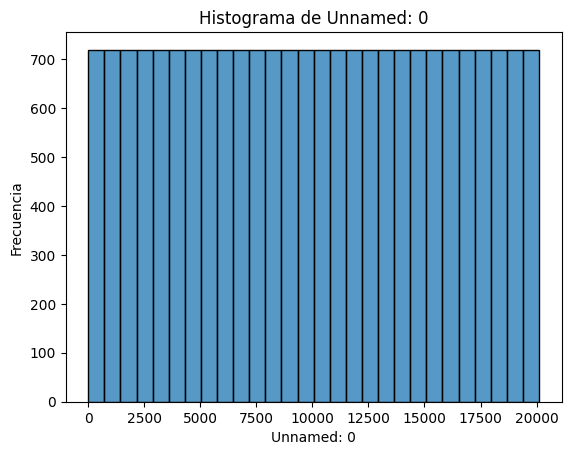

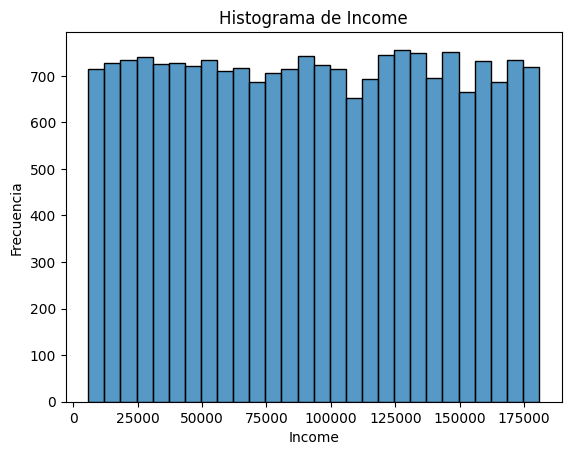

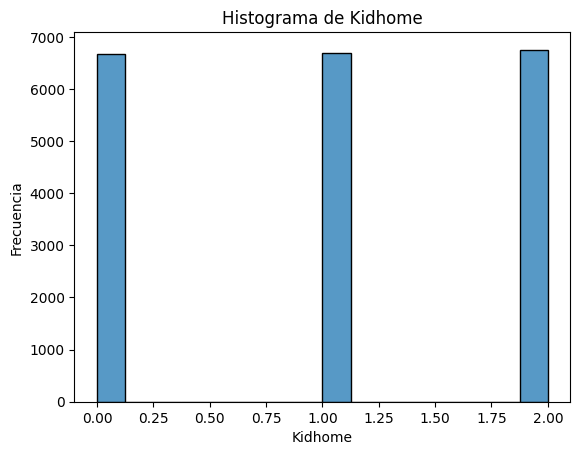

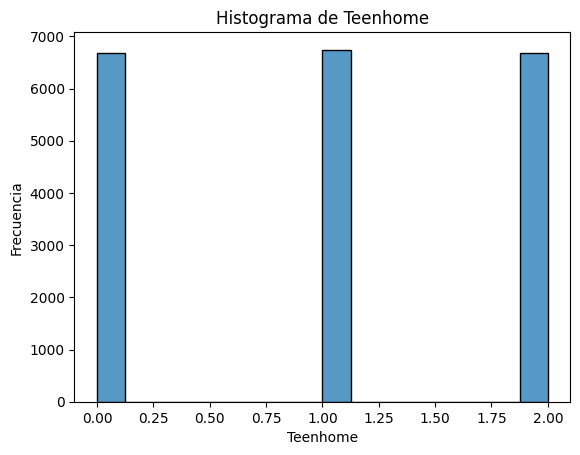

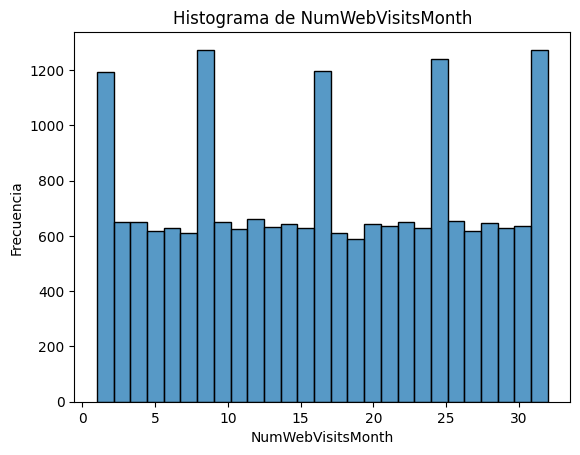

In [28]:
for col in columnas_num:
    plt.figure()
    sns.histplot(df_2012[col])
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

### Boxplot

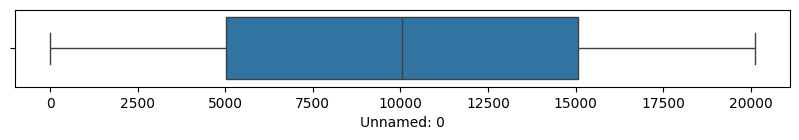

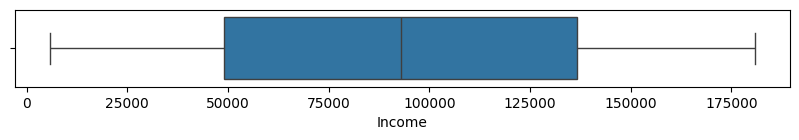

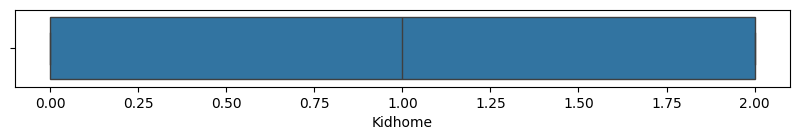

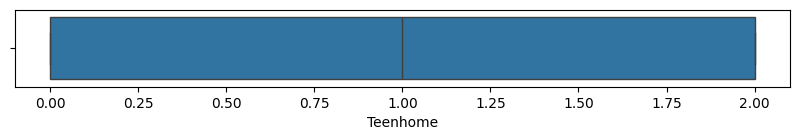

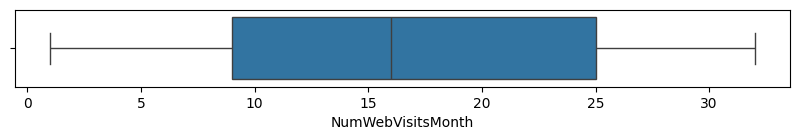

In [29]:
for col in columnas_num:

    plt.figure(figsize=(10, 1))
    sns.boxplot(x=df_2012[col])
    plt.show()

## Columnas categóricas

In [30]:
df_2012.describe(include=['category', 'object']).T

,count,unique,top,freq
ID,20115,20115,8299f0a6-e4c0-49fc-87ab-81308b70f80f,1


In [31]:
columnas_cat = df_2012.describe(include=['category', 'object']).columns

columnas_cat

Index(['ID'], dtype='object')

In [32]:
for col in columnas_cat:

    print(f"La columna {col} tiene un total de {df_2012[col].nunique()} valores distintos:\n")

    print("Los 10 valores más repetidos son:")
    display(df_2012[col].value_counts(dropna=False).head(10))

La columna ID tiene un total de 20115 valores distintos:

Los 10 valores más repetidos son:


ID
8299f0a6-e4c0-49fc-87ab-81308b70f80f    1
089b39d8-e4d0-461b-87d4-814d71e0e079    1
e9d37224-cb6f-4942-98d7-46672963d097    1
71100141-53d0-4913-9750-f730875080c7    1
afd96190-4abd-404c-87a6-74cc40caebec    1
1f04ebce-3ae8-4e7f-8306-30742a537173    1
094b2662-7c1f-47e6-86c8-ec406f5373fc    1
942c997e-9f20-41ff-98b4-d2ad4b728610    1
812d6c96-fef7-4c94-84b7-69d3cfd1eb4e    1
7ca2bbf3-e280-4493-a010-6a51de92bf9d    1
Name: count, dtype: int64

### Observaciones rápidas:

* `ID`: Cada ID tiene un valor (código) diferente para cada usuario. Hay 20115 valores distintos.

### Countplot

In [87]:
df_2012 = pd.read_excel('../data/raw/customer-details.xlsx', sheet_name='2012')

In [88]:
columnas_cat = df_2012.select_dtypes(include=['category', 'object']).columns

In [89]:
for col in columnas_cat:

    if df_2012[col].nunique() > 200:
        print(f"Columna {col} tiene demasiadas categorías ({df_2012[col].nunique()}\n\n")
        continue

    print(f"Distribución de la columna {col}")
    plt.figure(figsize=(df_2012[col].nunique() * 2, 3))
    sns.countplot(x=df_2012[col], order=df_2012[col].value_counts().index)
    plt.show()

Columna ID tiene demasiadas categorías (20115




## Seguimos con el análisis preliminar del año 2013

In [43]:
df_2013

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be
1,1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479
2,2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c
3,3,113859,1,1,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4
4,4,147317,0,0,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528
...,...,...,...,...,...,...,...
8960,8960,139839,0,0,2013-12-10,8,6f7a03ac-c1b9-4acf-a28b-37cc8254a92e
8961,8961,65516,0,2,2013-10-01,26,ed489dce-7ccf-46ad-a0d4-bb71c566fa40
8962,8962,56664,1,0,2013-12-07,13,01b3ac53-b1bd-450a-be11-6893b3aeadd5
8963,8963,25089,0,1,2013-08-24,14,8906c203-a13f-4b10-985c-bd72bd01a011


In [45]:
df_2013.sample(5)

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
3724,3724,99789,0,2,2013-05-16,25,ca226e91-a017-4b9a-9fbb-34562602f944
8215,8215,116589,0,1,2013-10-31,21,e5ed1f03-eb15-4443-ad23-09baa6efb855
4528,4528,24367,1,1,2013-11-27,10,96882ef3-0695-42bb-a35a-ec4f0425ad69
1267,1267,93926,1,0,2013-09-16,27,85b14376-392c-414e-898c-463aa47ca89f
7531,7531,10817,2,2,2013-04-29,31,ca17848e-32d9-4309-a092-154040e1c306


In [46]:
df_2013.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8965 entries, 0 to 8964
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         8965 non-null   int64         
 1   Income             8965 non-null   int64         
 2   Kidhome            8965 non-null   int64         
 3   Teenhome           8965 non-null   int64         
 4   Dt_Customer        8965 non-null   datetime64[ns]
 5   NumWebVisitsMonth  8965 non-null   int64         
 6   ID                 8965 non-null   object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 490.4+ KB


Las columnas del dataset son las mismas para 2012, 2013 y 2014.

## Análisis de fechas
Comprobar los valores únicos de los años para el intervalo de tiempo.

In [49]:
df_2013['Dt_Customer'].value_counts()

Dt_Customer
2013-02-18    41
2013-09-10    39
2013-01-10    38
2013-05-17    38
2013-12-22    37
              ..
2013-09-03    15
2013-08-30    15
2013-06-05    15
2013-10-18    13
2013-10-24    12
Name: count, Length: 365, dtype: int64

In [50]:
df_2013['Dt_Customer'].describe()

count                             8965
mean     2013-07-02 11:23:37.110987008
min                2013-01-01 00:00:00
25%                2013-04-01 00:00:00
50%                2013-07-03 00:00:00
75%                2013-10-03 00:00:00
max                2013-12-31 00:00:00
Name: Dt_Customer, dtype: object

## Duplicados

Vamos a eliminar duplicados.

In [52]:
df_2013.duplicated().sum()

np.int64(0)

No hay duplicados.

## Valores nulos

Comprobar el total de valores nulos que tenemos.

In [54]:
nulos = df_2013.isna().sum()

nulos

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

In [55]:
nulos = df_2013.isna().sum()

nulos[nulos > 0]

Series([], dtype: int64)

In [56]:
df_2013.isna().sum().sort_values(ascending=False)

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

In [57]:
nulos_porc = df_2013.isna().mean() * 100

nulos_porc[nulos_porc>0].round(2)

Series([], dtype: float64)

No hay nulos.

## Variables numéricas

In [58]:
columnas_num = df_2012.select_dtypes(include='number').columns

In [59]:
columnas_num

Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth'], dtype='object')

In [60]:
df_2012.describe(include='number').T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,20115.0,10057.00,5806.84,0.0,5028.5,10057.0,15085.5,20114.0
Income,20115.0,93087.21,50614.80,5852.0,49110.0,92962.0,136705.0,180791.0
Kidhome,20115.0,1.00,0.82,0.0,0.0,1.0,2.0,2.0
Teenhome,20115.0,1.00,0.82,0.0,0.0,1.0,2.0,2.0
NumWebVisitsMonth,20115.0,16.54,9.24,1.0,9.0,16.0,25.0,32.0


### Observaciones rápidas:

* `Unnamed: 0`: Esta columna vuelve a parecer. Tiene una media de 10057 y un rango de 0 a 20114, pero no tiene valor analítico. Debería eliminarse del DataFrame para evitar confusión o errores.

* `Income`: El ingreso promedio es de 93087.21, con una desviación estándar muy alta (50614.80), lo que indica que hay gran desigualdad económica entre los clientes. Los ingresos oscilan entre 5852 y 180791, lo que sugiere que el banco tiene clientes desde clase media baja hasta niveles altos. La media y la mediana son similares (~93k), lo que indica una distribución ligeramente simétrica.

* `Kidhome`: Esta variable oscila entre 0 y 2 niños por hogar. La media es 1.0 y la desviación estándar 0.82, lo que indica que la mayoría de los hogares tienen 1 niño o ninguno. Es una variable útil para identificar perfiles familiares.

* `Teenhome`: Presenta exactamente el mismo patrón estadístico que Kidhome. Rango de 0 a 2, media 1.0, y distribución muy parecida. Esto podría indicar un patrón común en el diseño de las encuestas o una relación fuerte entre ambas variables. Podría ser útil cruzarlas para analizar hogares con múltiples menores.

* `NumWebVisitsMonth`: Esta variable tiene un rango muy amplio (1 a 32 visitas mensuales), lo que muestra comportamientos digitales muy distintos entre clientes. La media (16.54) y la mediana (16) están muy cerca, lo que sugiere una distribución simétrica. Algunos clientes acceden a la web más de una vez al día, lo que podría ser un indicador de engagement alto o necesidad frecuente de servicios del banco.

### Histogramas

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

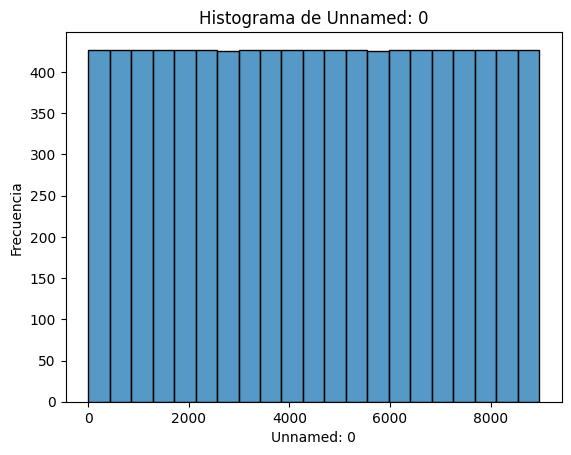

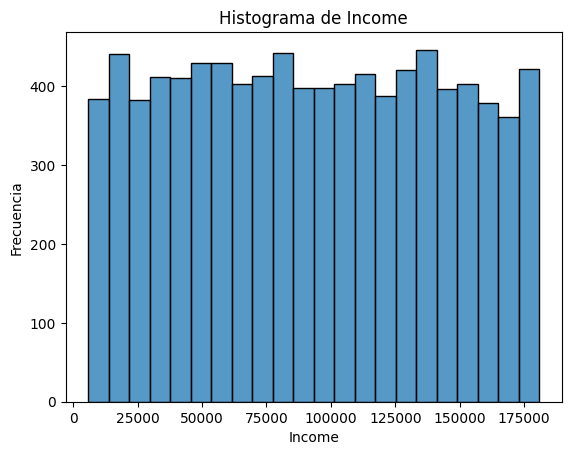

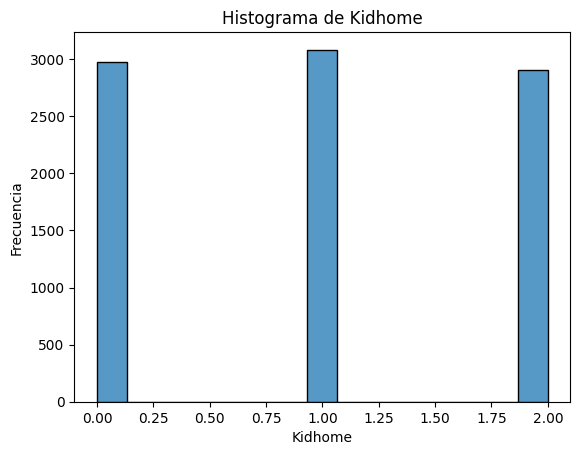

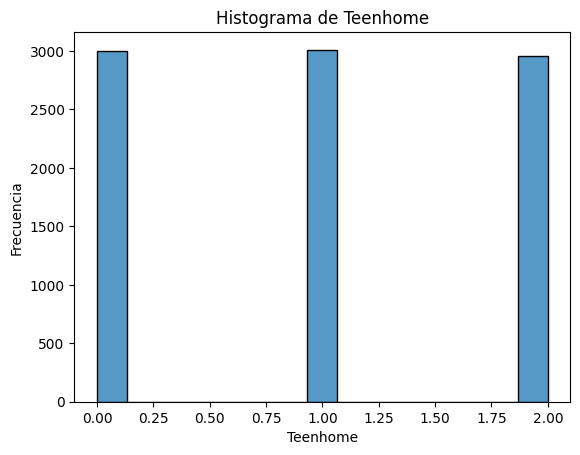

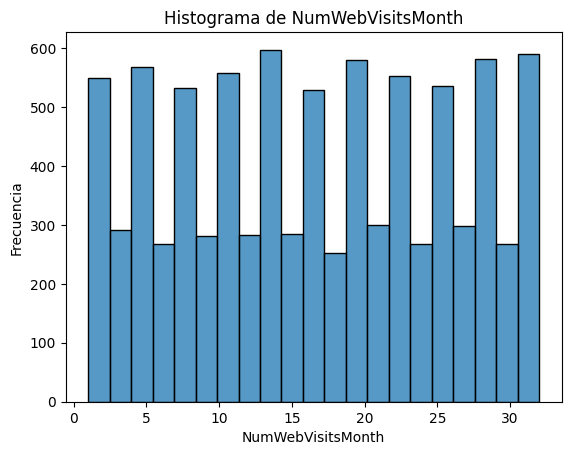

In [64]:
for col in columnas_num:
    plt.figure()
    sns.histplot(df_2013[col])
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

### Boxplot

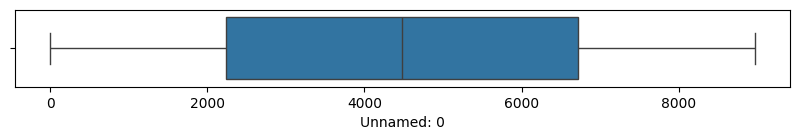

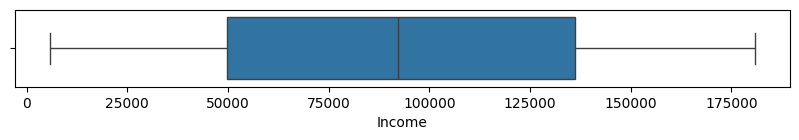

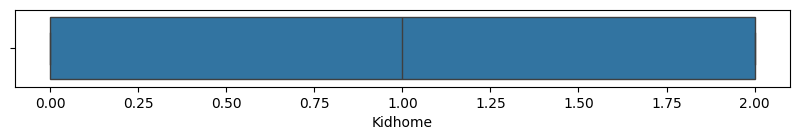

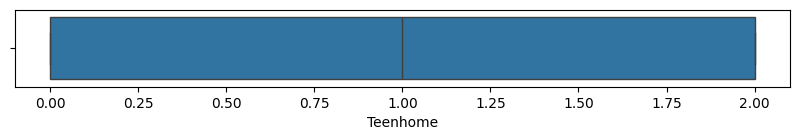

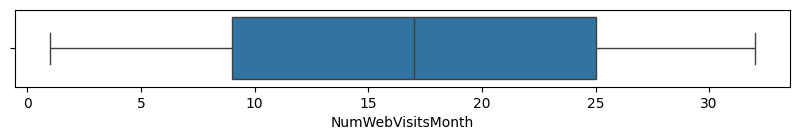

In [65]:
for col in columnas_num:

    plt.figure(figsize=(10, 1))
    sns.boxplot(x=df_2013[col])
    plt.show()

## Columnas categóricas

In [66]:
df_2013.describe(include=['category', 'object']).T

,count,unique,top,freq
ID,8965,8965,ba7fb638-c6cb-4dc8-aad4-75456c3818c5,1


In [67]:
columnas_cat = df_2013.describe(include=['category', 'object']).columns

columnas_cat

Index(['ID'], dtype='object')

In [68]:
for col in columnas_cat:

    print(f"La columna {col} tiene un total de {df_2013[col].nunique()} valores distintos:\n")

    print("Los 10 valores más repetidos son:")
    display(df_2013[col].value_counts(dropna=False).head(10))

La columna ID tiene un total de 8965 valores distintos:

Los 10 valores más repetidos son:


ID
ba7fb638-c6cb-4dc8-aad4-75456c3818c5    1
ef81336c-e41a-46d0-8a30-5d4ac3b836be    1
50b224ac-84b4-42a7-aba9-3e1d1d620479    1
9cb15c53-b647-464a-add9-09cdae04897c    1
f8aaf334-949d-4943-a214-b64fe9c088b4    1
da9abbf1-6385-4e1e-a5c5-febd4689e09c    1
fdac4a17-0b38-41c6-a2c7-7045fd409f22    1
fbb226fe-8b5d-4c34-a2b8-4b440e60e9a6    1
b2893243-7bfc-4a53-b851-1b52021f42a9    1
a58d6a79-a343-4164-947d-7a0e8f5a5666    1
Name: count, dtype: int64

### Observaciones rápidas:

* `ID`: Cada ID tiene un valor (código) diferente para cada usuario. Hay 8965 valores distintos.

### Countplot

In [81]:
df_2013 = pd.read_excel('../data/raw/customer-details.xlsx', sheet_name='2013')

In [82]:
columnas_cat = df_2013.select_dtypes(include=['category', 'object']).columns

In [83]:
for col in columnas_cat:

    if df_2013[col].nunique() > 200:
        print(f"Columna {col} tiene demasiadas categorías ({df_2013[col].nunique()}\n\n")
        continue

    print(f"Distribución de la columna {col}")
    plt.figure(figsize=(df_2013[col].nunique() * 2, 3))
    sns.countplot(x=df_2013[col], order=df_2013[col].value_counts().index)
    plt.show()

Columna ID tiene demasiadas categorías (8965




## Terminamos con el análisis preliminar del año 2014

In [90]:
df_2014

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,168812,1,1,2014-06-10,27,4d6c811c-0f24-4a73-b374-2ebd1f80d46e
1,1,108615,2,1,2014-04-05,24,eef0f24f-cbdb-4c67-b371-09d7bc59695e
2,2,179041,0,2,2014-09-22,4,bbfdcedd-199d-4927-94bb-5dad051ff471
3,3,116639,2,2,2014-08-16,3,e8ebb67d-4ee1-4615-b701-eefe3af607eb
4,4,49537,0,1,2014-09-05,28,f7f79ace-0024-4505-a401-f340946f0942
...,...,...,...,...,...,...,...
14085,14085,156980,1,2,2014-05-17,7,5f432048-d515-4bb5-9c94-62db451f88d4
14086,14086,139820,0,0,2014-09-29,1,993bbbd6-4dbc-4a40-a408-f91f8462bee6
14087,14087,78470,2,2,2014-10-28,12,d6271666-319d-42c8-a741-cb22bf2c2093
14088,14088,144218,0,1,2014-07-01,9,f67fbfa8-6573-414d-a805-b26a2f1b1ceb


In [91]:
df_2014.sample(5)

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
2058,2058,41215,1,0,2014-11-29,9,1fe0dc9f-fe22-4b3d-bde3-f9f9479da93d
11861,11861,20598,2,2,2014-02-07,12,d6527aff-ccaa-4b77-bd3e-2898d1f6fbf8
4671,4671,95133,0,0,2014-08-28,26,217cf652-5e52-444a-bafb-b65b458a04ae
296,296,147570,2,2,2014-08-16,23,d3fbf649-7c78-410d-b8b1-a5d0b86bceac
8762,8762,119611,1,2,2014-09-30,5,034dcb17-c010-4ba6-b328-ca96e06777fc


In [92]:
df_2014.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14090 entries, 0 to 14089
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         14090 non-null  int64         
 1   Income             14090 non-null  int64         
 2   Kidhome            14090 non-null  int64         
 3   Teenhome           14090 non-null  int64         
 4   Dt_Customer        14090 non-null  datetime64[ns]
 5   NumWebVisitsMonth  14090 non-null  int64         
 6   ID                 14090 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 770.7+ KB


Las columnas del dataset son las mismas para 2012, 2013 y 2014.

## Análisis de fechas
Comprobar los valores únicos de los años para el intervalo de tiempo.

In [94]:
df_2014['Dt_Customer'].value_counts()

Dt_Customer
2014-11-28    57
2014-05-09    55
2014-09-02    55
2014-09-07    55
2014-11-06    55
              ..
2014-10-27    25
2014-02-02    23
2014-11-16    23
2014-02-13    21
2014-09-04    19
Name: count, Length: 365, dtype: int64

In [95]:
df_2014['Dt_Customer'].describe()

count                            14090
mean     2014-07-01 16:25:06.430092288
min                2014-01-01 00:00:00
25%                2014-04-04 00:00:00
50%                2014-06-30 00:00:00
75%                2014-09-30 00:00:00
max                2014-12-31 00:00:00
Name: Dt_Customer, dtype: object

## Duplicados

Vamos a eliminar duplicados.

In [97]:
df_2014.duplicated().sum()

np.int64(0)

No hay duplicados.

## Valores nulos

Comprobar el total de valores nulos que tenemos.

In [99]:
nulos = df_2014.isna().sum()

nulos

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

In [100]:
nulos = df_2014.isna().sum()

nulos[nulos > 0]

Series([], dtype: int64)

In [101]:
df_2014.isna().sum().sort_values(ascending=False)

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

In [102]:
nulos_porc = df_2014.isna().mean() * 100

nulos_porc[nulos_porc>0].round(2)

Series([], dtype: float64)

No hay nulos.

## Variables numéricas

In [103]:
columnas_num = df_2014.select_dtypes(include='number').columns

In [104]:
columnas_num

Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth'], dtype='object')

In [105]:
df_2014.describe(include='number').T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,14090.0,7044.50,4067.58,0.0,3522.25,7044.5,10566.75,14089.0
Income,14090.0,93706.47,50527.97,5841.0,50180.25,93589.0,137195.50,180802.0
Kidhome,14090.0,1.01,0.82,0.0,0.00,1.0,2.00,2.0
Teenhome,14090.0,1.00,0.82,0.0,0.00,1.0,2.00,2.0
NumWebVisitsMonth,14090.0,16.67,9.24,1.0,9.00,17.0,25.00,32.0


### Observaciones rápidas:

* `Unnamed: 0`: Esta columna aparece de nuevo. Tiene una media de 7044.50 y un rango de 0 a 14089, pero no tiene valor analítico. Debería eliminarse del DataFrame para evitar confusión o errores tal y cómo se ha comentado.

* `Income`: El ingreso promedio es de 93706.47, con una desviación estándar muy alta (50527.97), lo que indica que hay gran desigualdad económica entre los clientes. Los ingresos oscilan entre 5841 y 180802, lo que sugiere que el banco tiene clientes desde clase media baja hasta niveles altos. La media y la mediana son similares (~94k), lo que indica una distribución ligeramente simétrica.

* `Kidhome`: Esta variable oscila entre 0 y 2 niños por hogar. La media es 1.0 y la desviación estándar 0.82, lo que indica que la mayoría de los hogares tienen 1 niño o ninguno. Es una variable útil para identificar perfiles familiares.

* `Teenhome`: Presenta exactamente el mismo patrón estadístico que Kidhome. Rango de 0 a 2, media 1.0, y distribución muy parecida. Esto podría indicar un patrón común en el diseño de las encuestas o una relación fuerte entre ambas variables. Podría ser útil cruzarlas para analizar hogares con múltiples menores.

* `NumWebVisitsMonth`: Esta variable tiene un rango muy amplio (1 a 32 visitas mensuales), lo que muestra comportamientos digitales muy distintos entre clientes. La media (16.67) y la mediana (17) están muy cerca, lo que sugiere una distribución simétrica. Algunos clientes acceden a la web más de una vez al día, lo que podría ser un indicador de engagement alto o necesidad frecuente de servicios del banco.

### Histogramas

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

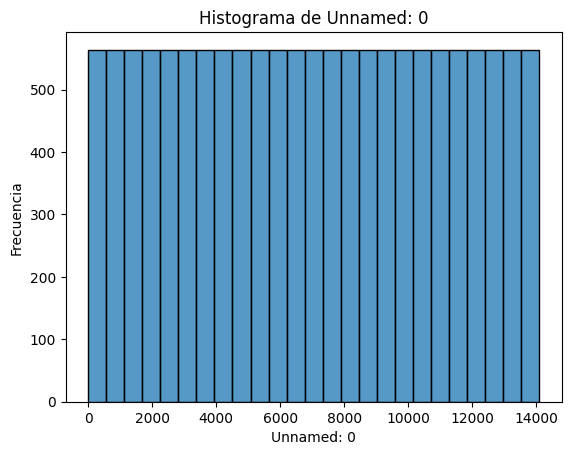

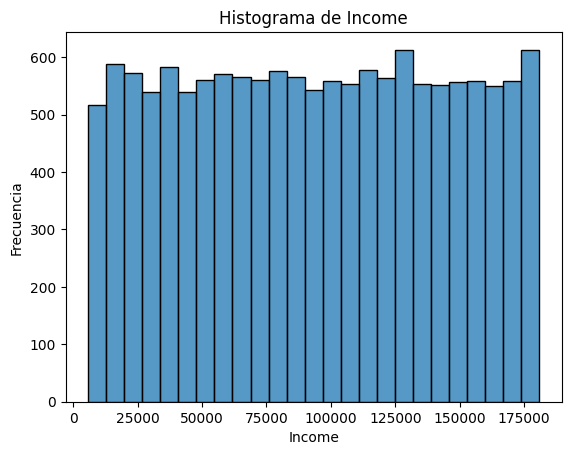

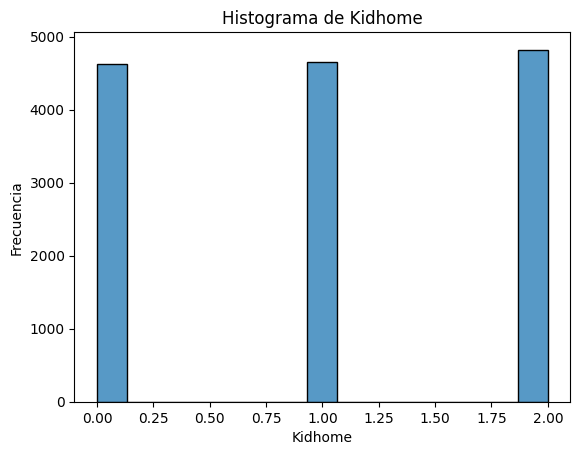

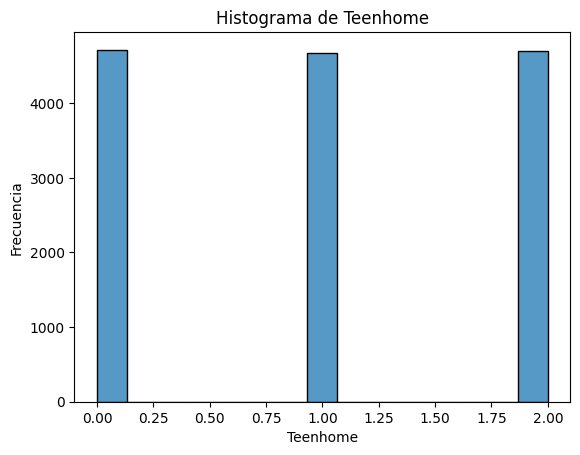

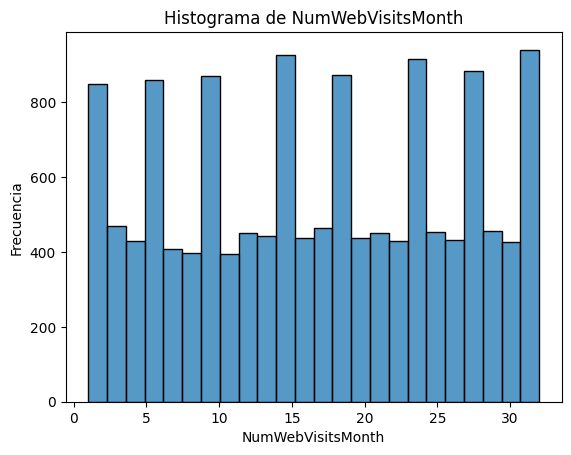

In [109]:
for col in columnas_num:
    plt.figure()
    sns.histplot(df_2014[col])
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

### Boxplot

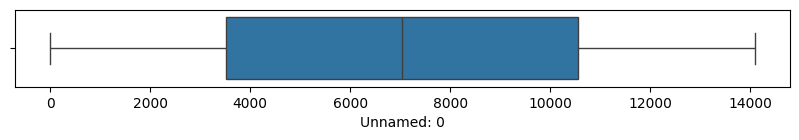

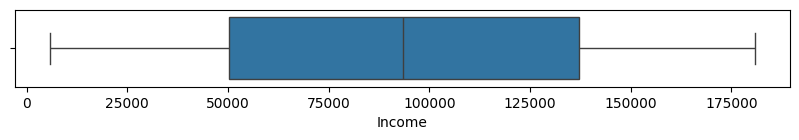

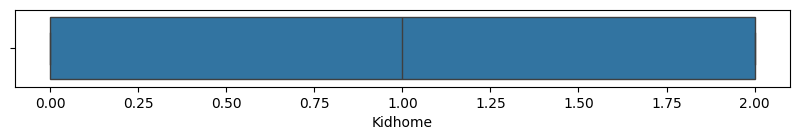

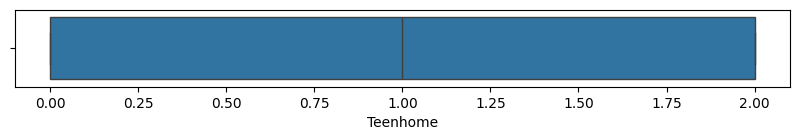

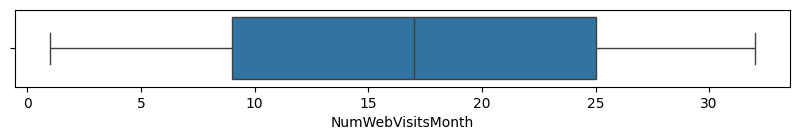

In [110]:
for col in columnas_num:

    plt.figure(figsize=(10, 1))
    sns.boxplot(x=df_2014[col])
    plt.show()

## Columnas categóricas

In [111]:
df_2014.describe(include=['category', 'object']).T

,count,unique,top,freq
ID,14090,14090,9727bc06-c11a-461a-a5bb-3d210467cc2a,1


In [112]:
columnas_cat = df_2014.describe(include=['category', 'object']).columns

columnas_cat

Index(['ID'], dtype='object')

In [113]:
for col in columnas_cat:

    print(f"La columna {col} tiene un total de {df_2014[col].nunique()} valores distintos:\n")

    print("Los 10 valores más repetidos son:")
    display(df_2014[col].value_counts(dropna=False).head(10))

La columna ID tiene un total de 14090 valores distintos:

Los 10 valores más repetidos son:


ID
9727bc06-c11a-461a-a5bb-3d210467cc2a    1
4d6c811c-0f24-4a73-b374-2ebd1f80d46e    1
eef0f24f-cbdb-4c67-b371-09d7bc59695e    1
bbfdcedd-199d-4927-94bb-5dad051ff471    1
e8ebb67d-4ee1-4615-b701-eefe3af607eb    1
f7f79ace-0024-4505-a401-f340946f0942    1
e8b3bb16-3ccc-4915-b6ba-47bb369580e0    1
c44af86f-ee10-443d-98ac-e4433a56809d    1
99c06680-56e7-4fb4-b48e-a0d337436915    1
63fb1369-ff86-4a22-a492-c8dcaa6c0860    1
Name: count, dtype: int64

### Observaciones rápidas:

* `ID`: Cada ID tiene un valor (código) diferente para cada usuario. Hay 14090 valores distintos.

### Countplot

In [114]:
df_2014 = pd.read_excel('../data/raw/customer-details.xlsx', sheet_name='2014')

In [115]:
columnas_cat = df_2014.select_dtypes(include=['category', 'object']).columns

In [116]:
for col in columnas_cat:

    if df_2014[col].nunique() > 200:
        print(f"Columna {col} tiene demasiadas categorías ({df_2014[col].nunique()}\n\n")
        continue

    print(f"Distribución de la columna {col}")
    plt.figure(figsize=(df_2014[col].nunique() * 2, 3))
    sns.countplot(x=df_2014[col], order=df_2014[col].value_counts().index)
    plt.show()

Columna ID tiene demasiadas categorías (14090




## Diferencias entre los años 2012, 2013 y 2014. Resumen

* Estructura de los datos:

    * Todos los años tienen 7 columnas y 0 valores nulos, lo que indica una estructura limpia y consistente.
    * No hay columnas duplicadas.

* Ingresos promedio:

    * 2012: 93087.21
    * 2013: 93087.21
    * 2014: 93706.47
    
    Ingresos estables entre años, con una ligera tendencia al alza en 2014.

* Niños y adolescentes:

    * Entre 0 y 2 por hogar.

* Valores únicos de las fechas (máx y min):
    * 2012-08-10    79 valores
    * 2012-01-11    79 valores
    * 2012-12-28    75 valores
    * 2012-08-13    72 valores
    * 2012-11-25    72 valores
              ...
    * 2012-07-08    40 valores
    * 2012-02-03    40 valores
    * 2012-01-10    39 valores
    * 2012-01-31    37 valores
    * 2012-05-02    35 valores

* Promedio de visitas web mensuales:

    * 2012: 16.54
    * 2013: 16.54
    * 2014: 16.67

    Interacción web ligeramente creciente a partir de 2014.

* Número de clientes registrados:

    * 2012: 20115 registros
    * 2013: 8965 registros
    * 2014: 14090 registros

    El año 2013 presenta una caída importante en registros frente a 2012 y 2014.